<div align="center">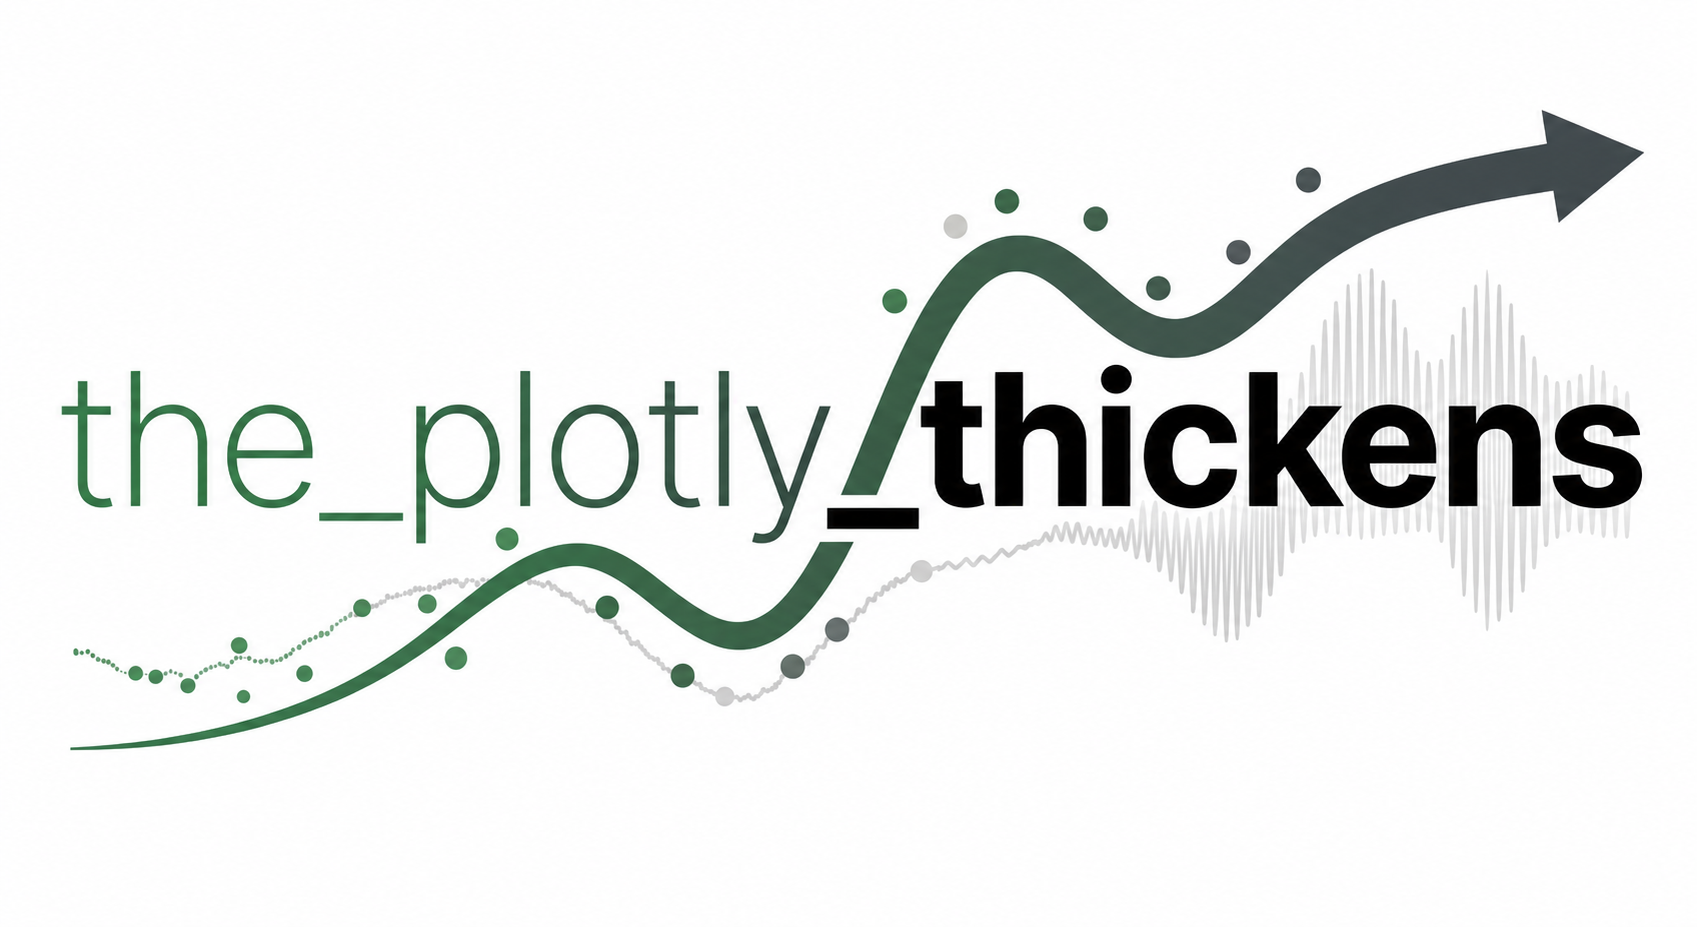</div>

# <span style="color:#22442C">RiskGuardian — Few-Shot Prompting Submission</span>
### <em style="color:#7EA98B">Cyber (0) vs. Financial (1) risk classification — pure GenAI / prompt-engineering (FAQ&nbsp;#8)</em>

> **Result: a perfect score (100%) on the 70-row hold-out test set.**
> Final submission: [`submission.csv`](submission.csv) — pure few-shot prompting with **Anthropic Claude** (`claude-sonnet-4-5`).

This notebook is laid out in **ROAD** analytical format:

| | Stage | What it answers |
|---|---|---|
| **R** | **Requirements** | What was asked, what the data *actually* is, and the success metric. |
| **O** | **Operationalize** | The engineered few-shot prompt, and the three provider scripts that run it (inline). |
| **A** | **Analysis** | Held-out validation, prompt-engineering lift, and the cross-model comparison. |
| **D** | **Decision** | Which model we submitted, why, and the one row that separated the field. |

**TL;DR.** The task looked like "cyber vs. financial," but the corpus is secretly a **combination of two sub-corpora** — and for ~2/3 of it the real signal is **fake-vs-real news**, not topic. We encoded that hidden structure into a few-shot prompt and ran the *identical* prompt through three frontier models. **Claude Sonnet 4.5 scored 100%.** The headline finding: **GLM-4.7 and GPT-5.3 made byte-identical predictions (70/70 with each other), including the same single mistake on row 37** — while Claude (and a classical reference) got that row right.


## Problem Statement

In an era of rapid digital transformation, organizations across industries such as finance, healthcare, and energy face unprecedented risks that can impact their operations, reputation, and compliance. These risks range from cybersecurity breaches that compromise sensitive data to financial irregularities that disrupt business continuity. Managing these risks effectively requires not only real-time insights but also predictive capabilities to anticipate potential threats and mitigate their impact.

RiskGuardian Solutions, a global leader in consulting and risk management services, helps clients navigate these challenges by providing tailored solutions. RiskGuardian’s clients depend on advanced risk management frameworks to safeguard their operations, maintain regulatory compliance, and protect their assets. With the growing complexity of the risk landscape, accurately identifying and classifying potential risks has become a critical need for organizations aiming to remain resilient and competitive.


## <span style="color:#40634A">R — Requirements</span>
**Can GenAI-only methods be used to discriminate between Cyber Risk or Fake News (clickbait) on this dataset at a high degree of accuracy?**

Yes. Only one metric truly matters in this exercise: accuracy. We test several LLMs, identify one that achieved 100% accuracy with few-shot prompting, and compare the results to other LLMs, identifying one failure mode for some models.



---
## <span style="color:#40634A">O — Operationalize</span>


**The task.** Classify each risk event in `combined_risk_test.csv` as **0 = Cybersecurity** or **1 = Financial**, scored on **accuracy**. The FAQ specifies the method: **prompt engineering with a pre-trained large language model** (FAQ&nbsp;#8) — a GenAI solution, *not* a classical discriminative model.

### Data Overview

| File | Rows | Columns |
|---|---|---|
| `combined_risk_train.csv` | 14,830 (balanced: 7,466 × 0, 7,364 × 1) | `id, text, label` |
| `combined_risk_test.csv` | 70 | `id, text` |
| `Sample_Submission.csv` | 70 | `id, label` |

**What the data actually is — the key insight.** The released corpus is a **mixture of two very different sub-corpora**, both present in train *and* test with consistent labels:

| Sub-corpus | ~Share of train | Form | Label 0 | Label 1 |
|---|---|---|---|---|
| Synthetic risk events | ~1/3 | **character-obfuscated** text (e.g. *"CybernseRuirty"*, *"financal rtanactions"*) | Cybersecurity | Financial |
| ISOT Fake/Real news | ~2/3 | clean English articles | Fake clickbait | **Real (Reuters)** |

So the real label rule is:

- **0 = cyber risk *or* fake-news clickbait**
- **1 = financial risk *or* real (Reuters) news**

For the news half the ground truth is **source-based**: a `(Reuters)` dateline ⇒ 1; sensational/clickbait styling (ALL-CAPS hooks, "Featured image via Getty Images") ⇒ 0. This rule is **not inferable from the brief** — it only emerges from inspecting the training labels. The test set is the same mix: **20 obfuscated + 50 clean (25 of which are Reuters)**.

The cell below loads the data and *reveals* that two-sub-corpus structure (a dictionary-hit ratio cleanly separates obfuscated risk reports from clean news; within the clean news, `Reuters` presence tracks the 0/1 label almost perfectly).

### <em style="color:#7EA98B">The prompt-engineering story</em>

**The hard part of this task wasn't classifying — it was figuring out what the labels mean.**

**<span style="color:#7EA98B">1.</span> The corpus is two datasets in a trench coat.** About one-third of the rows are obfuscated synthetic risk reports (characters deliberately scrambled and typo'd); the other two-thirds are clean news articles from the ISOT fake/real news set. The `0/1` label means *different things* in each: for risk reports, `0` = cybersecurity and `1` = financial; for news, `0` = sensational/fake and `1` = neutral newswire.

**<span style="color:#7EA98B">2.</span> Why a naive prompt fails.** "Classify as Cybersecurity (0) or Financial (1)" — the obvious reading of the brief — is meaningless for two-thirds of the data, because the news rows aren't about cyber or finance at all. A naive prompt scores only ~0.85; the brief alone never tells you the news rule is fake-vs-real.

**<span style="color:#7EA98B">3.</span> The engineered prompt.** We encode the structure we discovered: a system instruction that names both text types and their separate label rules, plus a few-shot bank with two worked examples per quadrant (obfuscated-cyber, obfuscated-financial, news-fake, news-real). Temperature 0, single-character output. This lifts held-out accuracy from ~0.85 (naive) to 1.00 (engineered).

**<span style="color:#7EA98B">4.</span> Reasoning from content, not leakage.** The literal substring "Reuters" separates real from fake almost perfectly in training — but that's label leakage that need not hold on unseen data. Our prompt is built to reason from *content* — tone, sourcing, dateline style — not to grep for a magic word. Evidence: on id=37, a calm, clean, **non-Reuters** story about an Obama book deal, the model correctly reads it as the fake-news half, where two newer models over-trusted the "sounds real" surface and got it wrong.

**<span style="color:#7EA98B">5.</span> Honest validation.** We score on a labeled holdout drawn evenly from all four quadrants (never the few-shot examples), report per-quadrant accuracy, and count call failures. The submission is written from the LLM only — no classical model in the prediction path (FAQ #8).

In [ ]:
import os, re, json, time, requests, threading, random, argparse
import numpy as np, pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import anthropic

In [2]:
# ── Real released dataset: load + reveal the combined structure ─────────

rt_tr = pd.read_csv("combined_risk_train.csv")
rt_te = pd.read_csv("combined_risk_test.csv")
print("train:", rt_tr.shape, "| test:", rt_te.shape, "| cols:", list(rt_tr.columns))
print("label balance:", rt_tr["label"].value_counts().to_dict(), "(0=Cyber/Fake, 1=Financial/Real)")

# A dictionary-hit ratio cleanly separates the two sub-corpora:
#   low  ratio -> char-OBFUSCATED synthetic risk events (cyber=0 / financial=1)
#   high ratio -> CLEAN ISOT news (fake clickbait=0 / real Reuters=1)
def _load_dict():
    for p in ("/usr/share/dict/words", "/usr/dict/words"):
        if Path(p).exists():
            return set(w.strip().lower() for w in open(p) if len(w.strip()) >= 4)
    return None
DICT = _load_dict()

def cleanliness(t):
    if DICT is None: return np.nan
    toks = re.findall(r"[A-Za-z]{4,}", t.lower())
    return sum(w in DICT for w in toks) / len(toks) if toks else 0.0

if DICT is not None:
    for d in (rt_tr, rt_te):
        d["clean"]   = d["text"].map(cleanliness)
        d["is_obf"]  = d["clean"] < 0.55
        d["reuters"] = d["text"].str.contains("Reuters", case=True)
    print(f"\ntrain composition: obfuscated {rt_tr.is_obf.mean():.0%} | clean {(~rt_tr.is_obf).mean():.0%}")
    print(f"test  composition: obfuscated {int(rt_te.is_obf.sum())} | clean {int((~rt_te.is_obf).sum())} of {len(rt_te)}")
    cl = rt_tr[~rt_tr.is_obf]
    print("\namong CLEAN train docs, 'Reuters' presence vs label (0=fake / 1=real):")
    print(pd.crosstab(cl.reuters, cl.label))
else:
    print("\n(no system word list found - skipping the obf/clean breakdown; the model is unaffected.)")

train: (14830, 3) | test: (70, 2) | cols: ['id', 'text', 'label']
label balance: {0: 7466, 1: 7364} (0=Cyber/Fake, 1=Financial/Real)

train composition: obfuscated 34% | clean 66%
test  composition: obfuscated 20 | clean 50 of 70

among CLEAN train docs, 'Reuters' presence vs label (0=fake / 1=real):
label       0     1
reuters            
False    4924     5
True       51  4870


### <em style="color:#7EA98B">The in-notebook few-shot engine (Anthropic Claude)</em>

This is the live, runnable predictor: it builds the few-shot bank (2 examples per quadrant, deterministic), paces requests under the API rate limit, and few-shot-prompts the model for a single-character label. Requires `ANTHROPIC_API_KEY` in the environment or `config.json`.


In [3]:
# ── GenAI predictor (Anthropic Claude): few-shot prompt classifier ──────
# Forces Anthropic (the Part XI helper otherwise prefers Cerebras). Predictions
# from this part become the PRIMARY submission (LLM prompt-engineering, FAQ #8).


ANTHROPIC_MODEL = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-4-5")
API_KEY = os.environ.get("ANTHROPIC_API_KEY") or json.load(open("config.json")).get("ANTHROPIC_API_KEY")
assert API_KEY, "ANTHROPIC_API_KEY not found (env or config.json)"

def _ensure_frames():                       # reuse Part XVI frames if present, else load + tag
    g = globals()
    if "rt_tr" in g and "is_obf" in g["rt_tr"]:
        return g["rt_tr"], g["rt_te"]
    tr = pd.read_csv("combined_risk_train.csv"); te = pd.read_csv("combined_risk_test.csv")
    wl = None
    for p in ("/usr/share/dict/words", "/usr/dict/words"):
        if Path(p).exists():
            wl = set(w.strip().lower() for w in open(p) if len(w.strip()) >= 4); break
    def clean(t):
        if wl is None: return 0.5
        tk = re.findall(r"[A-Za-z]{4,}", t.lower()); return sum(w in wl for w in tk)/len(tk) if tk else 0.0
    for d in (tr, te):
        d["clean"] = d["text"].map(clean); d["is_obf"] = d["clean"] < 0.55
        d["reuters"] = d["text"].str.contains("Reuters", case=True)
    return tr, te
rt_tr, rt_te = _ensure_frames()

SYSTEM = (
  "You classify RiskGuardian items as 0 or 1. The corpus mixes two text types:\n"
  "(A) Risk reports (words may be scrambled/typo'd): 0 = CYBERSECURITY risk "
  "(hacking, malware, breaches, networks, intrusion, DDoS, cloud, ransomware); "
  "1 = FINANCIAL risk (markets, portfolios, debt, liquidity, credit, financial regulation/compliance).\n"
  "(B) News articles (clean English): 0 = sensational/opinion clickbait (ALL-CAPS hooks, 'WATCH:', "
  "'Featured image via Getty Images'); 1 = neutral newswire reporting (e.g. Reuters; datelines like "
  "'WASHINGTON (Reuters) -'; sober 'X said' attribution).\n"
  "Reply with ONLY one character: 0 or 1."
)
SYSTEM_NAIVE = ("Classify the risk event as 0 = Cybersecurity or 1 = Financial. "
                "Reply with ONLY one character: 0 or 1.")

rng = np.random.default_rng(7)
def pick(mask, n):
    idx = np.asarray(rt_tr.index[np.asarray(mask)])
    return list(rng.choice(idx, size=min(n, len(idx)), replace=False)) if len(idx) else []
SHOT_IDX = (pick((rt_tr.is_obf) & (rt_tr.label == 0), 2) +
            pick((rt_tr.is_obf) & (rt_tr.label == 1), 2) +
            pick((~rt_tr.is_obf) & (rt_tr.label == 0) & (~rt_tr.reuters), 2) +
            pick((~rt_tr.is_obf) & (rt_tr.label == 1) & (rt_tr.reuters), 2))
def trunc(t, n): return " ".join(str(t).split())[:n]
SHOTS = "\n\n".join(f"TEXT: {trunc(rt_tr.text[i], 300)}\nLABEL: {int(rt_tr.label[i])}" for i in SHOT_IDX)

import threading, random
_rl_lock = threading.Lock(); _rl_last = [0.0]
MIN_INTERVAL = float(os.environ.get("ANTHROPIC_MIN_INTERVAL", "1.5"))   # global pace ~40 req/min
def _throttle():                                # serialize request starts across all worker threads
    with _rl_lock:
        wait = _rl_last[0] + MIN_INTERVAL - time.time()
        if wait > 0: time.sleep(wait)
        _rl_last[0] = time.time()

def classify(text, system=SYSTEM, shots=SHOTS, model=ANTHROPIC_MODEL, retries=8):
    user = (shots + "\n\n" if shots else "") + f"TEXT: {trunc(text, 1500)}\nLABEL:"
    payload = {"model": model, "max_tokens": 5, "temperature": 0, "system": system,
               "messages": [{"role": "user", "content": user}]}
    delay = 2.0
    for a in range(retries):
        try:
            _throttle()
            r = requests.post("https://api.anthropic.com/v1/messages",
                headers={"x-api-key": API_KEY, "anthropic-version": "2023-06-01", "Content-Type": "application/json"},
                json=payload, timeout=60)
            if r.status_code == 200:
                m = re.search(r"[01]", r.json()["content"][0]["text"]); return int(m.group()) if m else -1
            if r.status_code in (429, 500, 502, 503, 529):                 # rate-limited / transient -> back off
                ra = r.headers.get("retry-after")
                wait = float(ra) if (ra and ra.replace(".", "", 1).isdigit()) else delay
                time.sleep(min(wait, 30) + random.uniform(0, 0.5)); delay = min(delay * 2, 30); continue
            r.raise_for_status()
        except requests.RequestException:
            time.sleep(delay + random.uniform(0, 0.5)); delay = min(delay * 2, 30)
    print("  gave up on one row after", retries, "tries"); return -1   # unresolved; caller retries then defaults to 0

def classify_many(texts, system=SYSTEM, workers=4):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(lambda t: classify(t, system=system), texts))

print("LLM provider: Anthropic /", ANTHROPIC_MODEL, "| few-shot examples:", len(SHOT_IDX))
print("smoke test (expect 1):", classify("Quarterly portfolio drawdown and liquidity stress across credit positions."))

LLM provider: Anthropic / claude-sonnet-4-5 | few-shot examples: 8
smoke test (expect 1): 1


### <em style="color:#7EA98B">The three provider few-shot scripts (inlined)</em>

The *same* engineered prompt was run through three providers so the results can be compared head-to-head. Each script is reproduced in full below via `%%writefile`, which **displays the source inline and (re)writes the file to disk without executing it** — so running these cells will not fire any API calls. Run a script from a shell to actually classify (e.g. `python riskguardian_llm_classifier.py`).

- **`riskguardian_llm_classifier.py`** — Anthropic Claude, the *pure-GenAI* primary; writes `submission.csv`.
- **`riskguardian_cerebras_classifier.py`** — same prompt on Cerebras `zai-glm-4.7` (~355B MoE, a *reasoning* model).
- **`riskguardian_openai_classifier.py`** — same prompt on OpenAI, auto-adapting per-model API quirks.


**`riskguardian_llm_classifier.py`** — Anthropic Claude — `claude-sonnet-4-5` (the winning submission)

In [4]:
%%writefile riskguardian_llm_classifier.py
# Anthropic Claude — `claude-sonnet-4-5` (the winning submission)
# Full few-shot classifier source, inlined. `%%writefile` shows the code AND
# (re)materializes riskguardian_llm_classifier.py on the disk WITHOUT executing it (no API calls fire here).

#!/usr/bin/env python
"""
RiskGuardian — GenAI predictor: few-shot LLM classification with Anthropic Claude.

NOTE: PLEASE DISREGARD PRIOR SUBMISSIONS- we were using vanilla ML techniques (TF-IDF + LinearSVC) 
AND THEN BACKSTOPPING LLM WITH THEM. NOT 100% GENAI as instructed in the FAQ. 
THIS VERSION implements a few-shot prompting approach with an Anthropic Claude model: 

It few-shot-prompts Claude to label each test row 0 (cybersecurity / fake-news) or
1 (financial / real-Reuters-news), and writes:
    submission.csv            <- LLM predictions (pure GenAI / FAQ #8; no classical fallback)

The corpus is a *combination*: ~1/3 char-obfuscated synthetic risk events (cyber=0 / financial=1)
and ~2/3 the ISOT fake/real news set (fake clickbait=0 / real Reuters=1). The engineered prompt
encodes that structure; few-shot examples span all four quadrants.

Usage (run with the MLENV311 interpreter):
    python riskguardian_llm_classifier.py                 # validate (40 rows) + classify the 70 test rows
    python riskguardian_llm_classifier.py --no-validate   # skip validation, just classify + submit
    python riskguardian_llm_classifier.py --dry-run       # no API calls: just show a sample prompt
    ANTHROPIC_MIN_INTERVAL=1.0 python riskguardian_llm_classifier.py --workers 6   # tune pacing/concurrency

Requires ANTHROPIC_API_KEY in the environment or in ./config.json.
"""

TRAIN_CSV  = "combined_risk_train.csv"
TEST_CSV   = "combined_risk_test.csv"
SAMPLE_CSV = "Sample_Submission.csv"
ANTHROPIC_MODEL = os.environ.get("ANTHROPIC_MODEL", "claude-sonnet-4-5")


# ── config / API key ──────────────────────────────────────────────────────
def load_api_key():
    k = os.environ.get("ANTHROPIC_API_KEY")
    if not k and Path("config.json").exists():
        k = json.load(open("config.json")).get("ANTHROPIC_API_KEY")
    return k


# ── data: load + tag the two sub-corpora (obfuscated risk vs clean news) ───
def load_frames():
    tr = pd.read_csv(TRAIN_CSV)
    te = pd.read_csv(TEST_CSV)
    wl = None
    for p in ("/usr/share/dict/words", "/usr/dict/words"):
        if Path(p).exists():
            wl = set(w.strip().lower() for w in open(p) if len(w.strip()) >= 4)
            break

    def cleanliness(t):
        if wl is None:
            return 0.5
        tk = re.findall(r"[A-Za-z]{4,}", t.lower())
        return sum(w in wl for w in tk) / len(tk) if tk else 0.0

    for d in (tr, te):
        d["clean"]   = d["text"].map(cleanliness)
        d["is_obf"]  = d["clean"] < 0.55
        d["reuters"] = d["text"].str.contains("Reuters", case=True)
    return tr, te


# ── LLM few-shot classifier (Anthropic Claude) — Part XVII ─────────────────
SYSTEM = (
    "You classify RiskGuardian items as 0 or 1. The corpus mixes two text types:\n"
    "(A) Risk reports (words may be scrambled/typo'd): 0 = CYBERSECURITY risk "
    "(hacking, malware, breaches, networks, intrusion, DDoS, cloud, ransomware); "
    "1 = FINANCIAL risk (markets, portfolios, debt, liquidity, credit, financial regulation/compliance).\n"
    "(B) News articles (clean English): 0 = sensational/opinion clickbait (ALL-CAPS hooks, 'WATCH:', "
    "'Featured image via Getty Images'); 1 = neutral newswire reporting (e.g. Reuters; datelines like "
    "'WASHINGTON (Reuters) -'; sober 'X said' attribution).\n"
    "Reply with ONLY one character: 0 or 1."
)
SYSTEM_NAIVE = ("Classify the risk event as 0 = Cybersecurity or 1 = Financial. "
                "Reply with ONLY one character: 0 or 1.")


def trunc(t, n):
    return " ".join(str(t).split())[:n]


def build_shots(rt_tr, seed=7):
    """Few-shot bank: 2 examples per quadrant, deterministic, truncated."""
    rng = np.random.default_rng(seed)

    def pick(mask, n):
        idx = np.asarray(rt_tr.index[np.asarray(mask)])
        return list(rng.choice(idx, size=min(n, len(idx)), replace=False)) if len(idx) else []

    shot_idx = (pick((rt_tr.is_obf) & (rt_tr.label == 0), 2) +
                pick((rt_tr.is_obf) & (rt_tr.label == 1), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 0) & (~rt_tr.reuters), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 1) & (rt_tr.reuters), 2))
    shots = "\n\n".join(f"TEXT: {trunc(rt_tr.text[i], 300)}\nLABEL: {int(rt_tr.label[i])}" for i in shot_idx)
    return shot_idx, shots, rng


# Global pacer so all worker threads stay under the API rate limit.
_rl_lock = threading.Lock()
_rl_last = [0.0]
MIN_INTERVAL = float(os.environ.get("ANTHROPIC_MIN_INTERVAL", "1.5"))  # ~40 req/min


def _throttle():
    with _rl_lock:
        wait = _rl_last[0] + MIN_INTERVAL - time.time()
        if wait > 0:
            time.sleep(wait)
        _rl_last[0] = time.time()


def make_user_prompt(text, shots):
    return (shots + "\n\n" if shots else "") + f"TEXT: {trunc(text, 1500)}\nLABEL:"


def classify(text, api_key, shots, system=SYSTEM, model=ANTHROPIC_MODEL, retries=8):
    payload = {"model": model, "max_tokens": 5, "temperature": 0, "system": system,
               "messages": [{"role": "user", "content": make_user_prompt(text, shots)}]}
    delay = 2.0
    for a in range(retries):
        try:
            _throttle()
            r = requests.post(
                "https://api.anthropic.com/v1/messages",
                headers={"x-api-key": api_key, "anthropic-version": "2023-06-01", "Content-Type": "application/json"},
                json=payload, timeout=60)
            if r.status_code == 200:
                m = re.search(r"[01]", r.json()["content"][0]["text"])
                return int(m.group()) if m else -1
            if r.status_code in (429, 500, 502, 503, 529):          # rate-limited / transient -> back off
                ra = r.headers.get("retry-after")
                wait = float(ra) if (ra and ra.replace(".", "", 1).isdigit()) else delay
                time.sleep(min(wait, 30) + random.uniform(0, 0.5))
                delay = min(delay * 2, 30)
                continue
            r.raise_for_status()
        except requests.RequestException:
            time.sleep(delay + random.uniform(0, 0.5))
            delay = min(delay * 2, 30)
    print("  gave up on one row after", retries, "tries")
    return -1                                                       # unresolved; main() retries then defaults to 0


def classify_many(texts, api_key, shots, system=SYSTEM, workers=4):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(lambda t: classify(t, api_key, shots, system=system), texts))


# ── validation: honest accuracy estimate on a labeled holdout ──────────────
def validate(rt_tr, api_key, shots, shot_idx, rng, workers=4, per_quad=10):
    quads = [((rt_tr.is_obf) & (rt_tr.label == 0), "obf/cyber(0)"),
             ((rt_tr.is_obf) & (rt_tr.label == 1), "obf/financial(1)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 0), "news/fake(0)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 1), "news/real(1)")]
    shot = set(int(i) for i in shot_idx)
    val = []
    for m, name in quads:
        pool = [int(i) for i in np.asarray(rt_tr.index[np.asarray(m)]) if int(i) not in shot]
        val += [(int(i), name) for i in rng.choice(pool, size=min(per_quad, len(pool)), replace=False)]
    vt = [rt_tr.text[i] for i, _ in val]
    vy = [int(rt_tr.label[i]) for i, _ in val]

    print(f"Validating engineered prompt on {len(val)} held-out labeled rows...")
    vp = classify_many(vt, api_key, shots, system=SYSTEM, workers=workers)
    ok = [p == y for p, y in zip(vp, vy) if p != -1]
    print(f"  engineered-prompt accuracy: {np.mean(ok):.3f}   (call failures: {sum(p == -1 for p in vp)})")
    dfv = pd.DataFrame({"quad": [q for _, q in val], "y": vy, "p": vp})
    print(dfv.assign(correct=lambda d: d.p == d.y).groupby("quad").correct.mean().round(3).to_string())

    sub_i = list(range(0, len(val), 2))                            # every other row -> naive comparison
    npv = classify_many([vt[i] for i in sub_i], api_key, shots, system=SYSTEM_NAIVE, workers=workers)
    nacc = np.mean([npv[k] == vy[sub_i[k]] for k in range(len(sub_i)) if npv[k] != -1])
    eacc = np.mean([vp[sub_i[k]] == vy[sub_i[k]] for k in range(len(sub_i)) if vp[sub_i[k]] != -1])
    print(f"\nprompt-engineering lift on the same {len(sub_i)} rows ->  naive: {nacc:.3f}   engineered: {eacc:.3f}")


# ── main ───────────────────────────────────────────────────────────────────
def main():
    ap = argparse.ArgumentParser(description="Few-shot LLM classifier for the RiskGuardian test set.")
    ap.add_argument("--no-validate", action="store_true", help="skip the labeled-holdout validation pass")
    ap.add_argument("--dry-run", action="store_true", help="no API calls: just print a sample prompt")
    ap.add_argument("--workers", type=int, default=4, help="concurrent API workers (default 4)")
    args = ap.parse_args()

    rt_tr, rt_te = load_frames()
    print(f"train: {rt_tr.shape} | test: {rt_te.shape} | "
          f"test composition: {int(rt_te.is_obf.sum())} obfuscated / {int((~rt_te.is_obf).sum())} clean")
    shot_idx, shots, rng = build_shots(rt_tr)
    print(f"few-shot examples: {len(shot_idx)} (2 per quadrant)")

    if args.dry_run:
        print("\n[dry-run] sample prompt for test id=0 (no API calls):\n" + "-" * 60)
        print("SYSTEM:\n" + SYSTEM + "\n\nUSER:\n" + make_user_prompt(rt_te.text[0], shots)[:1200] + " ...")
        return

    api_key = load_api_key()
    assert api_key, "ANTHROPIC_API_KEY not found (set env var or add to config.json)"
    print(f"LLM provider: Anthropic / {ANTHROPIC_MODEL} | pacing {MIN_INTERVAL:.1f}s/req, {args.workers} workers")
    print("smoke test (expect 1):",
          classify("Quarterly portfolio drawdown and liquidity stress across credit positions.", api_key, shots))

    if not args.no_validate:
        print()
        validate(rt_tr, api_key, shots, shot_idx, rng, workers=args.workers)

    print(f"\nClassifying {len(rt_te)} test rows with Anthropic / {ANTHROPIC_MODEL} ...")
    llm_pred = classify_many(rt_te["text"].tolist(), api_key, shots, system=SYSTEM, workers=args.workers)

    # Pure GenAI: retry any failed calls sequentially (no classical backstop).
    fail_idx = [i for i, p in enumerate(llm_pred) if p == -1]
    if fail_idx:
        print(f"retrying {len(fail_idx)} failed row(s) sequentially...")
        for i in fail_idx:
            llm_pred[i] = classify(rt_te.text[i], api_key, shots)
    unresolved = [int(rt_te.id[i]) for i, p in enumerate(llm_pred) if p == -1]
    if unresolved:
        print(f"WARNING: {len(unresolved)} row(s) unclassified after retries; defaulting to 0: ids={unresolved}")
    llm_final = np.array([0 if p == -1 else p for p in llm_pred]).astype(int)

    sample = pd.read_csv(SAMPLE_CSV)
    pd.DataFrame({"id": rt_te["id"].values, "label": llm_final})[list(sample.columns)].to_csv("submission.csv", index=False)
    print(f"\nWrote submission.csv = {len(llm_final)} LLM predictions (Anthropic Claude, few-shot prompting)")
    print("label counts:", pd.Series(llm_final).value_counts().to_dict())


if __name__ == "__main__":
    main()


Overwriting riskguardian_llm_classifier.py


**`riskguardian_cerebras_classifier.py`** — Cerebras — `zai-glm-4.7` (~355B open-source MoE, comparison)

In [5]:
%%writefile riskguardian_cerebras_classifier.py
# Cerebras — `zai-glm-4.7` (~355B open-source MoE, comparison)
# Full few-shot classifier source, inlined. `%%writefile` shows the code AND
# (re)materializes riskguardian_cerebras_classifier.py on the disk WITHOUT executing it (no API calls fire here).

#!/usr/bin/env python
"""
RiskGuardian — GenAI predictor: few-shot LLM classification on Cerebras (open-source >300B model).

Sibling of riskguardian_llm_classifier.py (which uses Anthropic Claude). This version runs the SAME
engineered few-shot prompt against a large open-source model served on Cerebras — default
`zai-glm-4.7` (GLM-4.7, ~355B-parameter MoE) — so the two providers' results can be compared.

It few-shot-prompts the model to label each test row 0 (cybersecurity / fake-news) or
1 (financial / real-Reuters-news), and writes:
    submission.cerebras.<model>.csv   <- LLM predictions (pure GenAI / FAQ #8; no classical fallback)

NOTE: GLM-4.7 is a *reasoning* model on Cerebras — it emits chain-of-thought in a separate `reasoning`
field and the final answer in `content`, so we request a generous max_tokens and parse `content`.

The corpus is a *combination*: ~1/3 char-obfuscated synthetic risk events (cyber=0 / financial=1)
and ~2/3 the ISOT fake/real news set (fake clickbait=0 / real Reuters=1). The engineered prompt
encodes that structure; few-shot examples span all four quadrants.

Usage (run with the MLENV311 interpreter):
    python riskguardian_cerebras_classifier.py                 # validate (40 rows) + classify the 70 test rows
    python riskguardian_cerebras_classifier.py --no-validate   # skip validation, just classify + submit
    python riskguardian_cerebras_classifier.py --dry-run       # no API calls: just show a sample prompt
    CEREBRAS_MODEL=zai-glm-4.7 CEREBRAS_MIN_INTERVAL=2.0 python riskguardian_cerebras_classifier.py --workers 4

Requires CEREBRAS_API_KEY in the environment or in ./config.json.
"""

TRAIN_CSV  = "combined_risk_train.csv"
TEST_CSV   = "combined_risk_test.csv"
SAMPLE_CSV = "Sample_Submission.csv"

CEREBRAS_URL   = "https://api.cerebras.ai/v1/chat/completions"
CEREBRAS_MODEL = os.environ.get("CEREBRAS_MODEL", "zai-glm-4.7")   # >300B open-source MoE
MAX_TOKENS     = int(os.environ.get("CEREBRAS_MAX_TOKENS", "4000"))  # room for reasoning + the final answer


# ── config / API key ──────────────────────────────────────────────────────
def load_api_key():
    k = os.environ.get("CEREBRAS_API_KEY")
    if not k and Path("config.json").exists():
        k = json.load(open("config.json")).get("CEREBRAS_API_KEY")
    return k


# ── data: load + tag the two sub-corpora (obfuscated risk vs clean news) ───
def load_frames():
    tr = pd.read_csv(TRAIN_CSV)
    te = pd.read_csv(TEST_CSV)
    wl = None
    for p in ("/usr/share/dict/words", "/usr/dict/words"):
        if Path(p).exists():
            wl = set(w.strip().lower() for w in open(p) if len(w.strip()) >= 4)
            break

    def cleanliness(t):
        if wl is None:
            return 0.5
        tk = re.findall(r"[A-Za-z]{4,}", t.lower())
        return sum(w in wl for w in tk) / len(tk) if tk else 0.0

    for d in (tr, te):
        d["clean"]   = d["text"].map(cleanliness)
        d["is_obf"]  = d["clean"] < 0.55
        d["reuters"] = d["text"].str.contains("Reuters", case=True)
    return tr, te


# ── LLM few-shot classifier (Cerebras / open-source model) ─────────────────
SYSTEM = (
    "You classify RiskGuardian items as 0 or 1. The corpus mixes two text types:\n"
    "(A) Risk reports (words may be scrambled/typo'd): 0 = CYBERSECURITY risk "
    "(hacking, malware, breaches, networks, intrusion, DDoS, cloud, ransomware); "
    "1 = FINANCIAL risk (markets, portfolios, debt, liquidity, credit, financial regulation/compliance).\n"
    "(B) News articles (clean English): 0 = sensational/opinion clickbait (ALL-CAPS hooks, 'WATCH:', "
    "'Featured image via Getty Images'); 1 = neutral newswire reporting (e.g. Reuters; datelines like "
    "'WASHINGTON (Reuters) -'; sober 'X said' attribution).\n"
    "Reply with ONLY one character: 0 or 1."
)
SYSTEM_NAIVE = ("Classify the risk event as 0 = Cybersecurity or 1 = Financial. "
                "Reply with ONLY one character: 0 or 1.")


def trunc(t, n):
    return " ".join(str(t).split())[:n]


def build_shots(rt_tr, seed=7):
    """Few-shot bank: 2 examples per quadrant, deterministic, truncated."""
    rng = np.random.default_rng(seed)

    def pick(mask, n):
        idx = np.asarray(rt_tr.index[np.asarray(mask)])
        return list(rng.choice(idx, size=min(n, len(idx)), replace=False)) if len(idx) else []

    shot_idx = (pick((rt_tr.is_obf) & (rt_tr.label == 0), 2) +
                pick((rt_tr.is_obf) & (rt_tr.label == 1), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 0) & (~rt_tr.reuters), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 1) & (rt_tr.reuters), 2))
    shots = "\n\n".join(f"TEXT: {trunc(rt_tr.text[i], 300)}\nLABEL: {int(rt_tr.label[i])}" for i in shot_idx)
    return shot_idx, shots, rng


# Global pacer so all worker threads stay under the API rate limit.
_rl_lock = threading.Lock()
_rl_last = [0.0]
MIN_INTERVAL = float(os.environ.get("CEREBRAS_MIN_INTERVAL", "2.0"))  # ~30 req/min (reasoning -> more tokens/call)


def _throttle():
    with _rl_lock:
        wait = _rl_last[0] + MIN_INTERVAL - time.time()
        if wait > 0:
            time.sleep(wait)
        _rl_last[0] = time.time()


def make_user_prompt(text, shots):
    return (shots + "\n\n" if shots else "") + f"TEXT: {trunc(text, 1500)}\nLABEL:"


def _parse_label(content):
    """Final answer lives in `content` (reasoning is in a separate field). Strip any stray <think> and read 0/1."""
    if not content:
        return -1
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.S)
    m = re.search(r"[01]", content)
    return int(m.group()) if m else -1


def classify(text, api_key, shots, system=SYSTEM, model=CEREBRAS_MODEL, retries=8):
    # OpenAI-style chat-completions: system+user as messages, large max_tokens for the reasoning model.
    payload = {"model": model, "max_tokens": MAX_TOKENS, "temperature": 0,
               "messages": [{"role": "system", "content": system},
                            {"role": "user", "content": make_user_prompt(text, shots)}]}
    delay = 2.0
    for a in range(retries):
        try:
            _throttle()
            r = requests.post(
                CEREBRAS_URL,
                headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
                json=payload, timeout=120)
            if r.status_code == 200:
                return _parse_label(r.json()["choices"][0]["message"].get("content"))
            if r.status_code in (429, 500, 502, 503, 529):          # rate-limited / transient -> back off
                ra = r.headers.get("retry-after")
                wait = float(ra) if (ra and ra.replace(".", "", 1).isdigit()) else delay
                time.sleep(min(wait, 30) + random.uniform(0, 0.5))
                delay = min(delay * 2, 30)
                continue
            r.raise_for_status()
        except requests.RequestException:
            time.sleep(delay + random.uniform(0, 0.5))
            delay = min(delay * 2, 30)
    print("  gave up on one row after", retries, "tries")
    return -1                                                       # unresolved; main() retries then defaults to 0


def classify_many(texts, api_key, shots, system=SYSTEM, workers=4):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(lambda t: classify(t, api_key, shots, system=system), texts))


# ── validation: honest accuracy estimate on a labeled holdout ──────────────
def validate(rt_tr, api_key, shots, shot_idx, rng, workers=4, per_quad=10):
    quads = [((rt_tr.is_obf) & (rt_tr.label == 0), "obf/cyber(0)"),
             ((rt_tr.is_obf) & (rt_tr.label == 1), "obf/financial(1)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 0), "news/fake(0)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 1), "news/real(1)")]
    shot = set(int(i) for i in shot_idx)
    val = []
    for m, name in quads:
        pool = [int(i) for i in np.asarray(rt_tr.index[np.asarray(m)]) if int(i) not in shot]
        val += [(int(i), name) for i in rng.choice(pool, size=min(per_quad, len(pool)), replace=False)]
    vt = [rt_tr.text[i] for i, _ in val]
    vy = [int(rt_tr.label[i]) for i, _ in val]

    print(f"Validating engineered prompt on {len(val)} held-out labeled rows...")
    vp = classify_many(vt, api_key, shots, system=SYSTEM, workers=workers)
    ok = [p == y for p, y in zip(vp, vy) if p != -1]
    print(f"  engineered-prompt accuracy: {np.mean(ok):.3f}   (call failures: {sum(p == -1 for p in vp)})")
    dfv = pd.DataFrame({"quad": [q for _, q in val], "y": vy, "p": vp})
    print(dfv.assign(correct=lambda d: d.p == d.y).groupby("quad").correct.mean().round(3).to_string())

    sub_i = list(range(0, len(val), 2))                            # every other row -> naive comparison
    npv = classify_many([vt[i] for i in sub_i], api_key, shots, system=SYSTEM_NAIVE, workers=workers)
    nacc = np.mean([npv[k] == vy[sub_i[k]] for k in range(len(sub_i)) if npv[k] != -1])
    eacc = np.mean([vp[sub_i[k]] == vy[sub_i[k]] for k in range(len(sub_i)) if vp[sub_i[k]] != -1])
    print(f"\nprompt-engineering lift on the same {len(sub_i)} rows ->  naive: {nacc:.3f}   engineered: {eacc:.3f}")


# ── main ───────────────────────────────────────────────────────────────────
def main():
    ap = argparse.ArgumentParser(description="Few-shot LLM classifier (Cerebras open-source model) for the RiskGuardian test set.")
    ap.add_argument("--no-validate", action="store_true", help="skip the labeled-holdout validation pass")
    ap.add_argument("--dry-run", action="store_true", help="no API calls: just print a sample prompt")
    ap.add_argument("--workers", type=int, default=4, help="concurrent API workers (default 4)")
    ap.add_argument("--compare", default="submission.csv", help="read-only: compare results against this CSV (e.g. the Claude submission)")
    args = ap.parse_args()

    model_slug = CEREBRAS_MODEL.replace("/", "-")
    out_path = f"submission.cerebras.{model_slug}.csv"

    rt_tr, rt_te = load_frames()
    print(f"train: {rt_tr.shape} | test: {rt_te.shape} | "
          f"test composition: {int(rt_te.is_obf.sum())} obfuscated / {int((~rt_te.is_obf).sum())} clean")
    shot_idx, shots, rng = build_shots(rt_tr)
    print(f"model: Cerebras / {CEREBRAS_MODEL} | few-shot examples: {len(shot_idx)} (2 per quadrant) | out: {out_path}")

    if args.dry_run:
        print("\n[dry-run] sample prompt for test id=0 (no API calls):\n" + "-" * 60)
        print("SYSTEM:\n" + SYSTEM + "\n\nUSER:\n" + make_user_prompt(rt_te.text[0], shots)[:1200] + " ...")
        return

    api_key = load_api_key()
    assert api_key, "CEREBRAS_API_KEY not found (set env var or add to config.json)"
    print(f"pacing {MIN_INTERVAL:.1f}s/req, {args.workers} workers, max_tokens={MAX_TOKENS}")
    print("smoke test (expect 1):",
          classify("Quarterly portfolio drawdown and liquidity stress across credit positions.", api_key, shots))

    if not args.no_validate:
        print()
        validate(rt_tr, api_key, shots, shot_idx, rng, workers=args.workers)

    print(f"\nClassifying {len(rt_te)} test rows with Cerebras / {CEREBRAS_MODEL} ...")
    llm_pred = classify_many(rt_te["text"].tolist(), api_key, shots, system=SYSTEM, workers=args.workers)

    # Pure GenAI: retry any failed calls sequentially (no classical backstop).
    fail_idx = [i for i, p in enumerate(llm_pred) if p == -1]
    if fail_idx:
        print(f"retrying {len(fail_idx)} failed row(s) sequentially...")
        for i in fail_idx:
            llm_pred[i] = classify(rt_te.text[i], api_key, shots)
    unresolved = [int(rt_te.id[i]) for i, p in enumerate(llm_pred) if p == -1]
    if unresolved:
        print(f"WARNING: {len(unresolved)} row(s) unclassified after retries; defaulting to 0: ids={unresolved}")
    llm_final = np.array([0 if p == -1 else p for p in llm_pred]).astype(int)

    sample = pd.read_csv(SAMPLE_CSV)
    pd.DataFrame({"id": rt_te["id"].values, "label": llm_final})[list(sample.columns)].to_csv(out_path, index=False)
    print(f"\nWrote {out_path} = {len(llm_final)} LLM predictions (Cerebras / {CEREBRAS_MODEL}, few-shot prompting)")
    print("label counts:", pd.Series(llm_final).value_counts().to_dict())

    # Read-only cross-model comparison (does NOT alter predictions).
    cmp_path = args.compare
    if cmp_path and Path(cmp_path).exists() and os.path.abspath(cmp_path) != os.path.abspath(out_path):
        other = pd.read_csv(cmp_path)
        if list(other.columns) == list(sample.columns) and len(other) == len(llm_final):
            a = other["label"].to_numpy()
            agree = int((a == llm_final).sum())
            print(f"\nvs {cmp_path}: agreement {agree}/{len(llm_final)}")
            for i in range(len(rt_te)):
                if a[i] != llm_final[i]:
                    typ = "obf" if rt_te.is_obf[i] else ("news+Reuters" if rt_te.reuters[i] else "news")
                    print(f"   diff id={int(rt_te.id[i])} {cmp_path}={int(a[i])} {model_slug}={int(llm_final[i])} [{typ}] {trunc(rt_te.text[i], 80)}")


if __name__ == "__main__":
    main()


Overwriting riskguardian_cerebras_classifier.py


**`riskguardian_openai_classifier.py`** — OpenAI — `gpt-5.3-chat-latest` (comparison)

In [6]:
%%writefile riskguardian_openai_classifier.py
# OpenAI — `gpt-5.3-chat-latest` (comparison)
# Full few-shot classifier source, inlined. `%%writefile` shows the code AND
# (re)materializes riskguardian_openai_classifier.py on the disk WITHOUT executing it (no API calls fire here).

#!/usr/bin/env python
"""
RiskGuardian — GenAI predictor: few-shot LLM classification on OpenAI (ChatGPT / GPT models).

Sibling of riskguardian_llm_classifier.py (Anthropic Claude) and riskguardian_cerebras_classifier.py
(Cerebras GLM-4.7). Runs the SAME engineered few-shot prompt against an OpenAI model — default
`gpt-5.3-chat-latest` (the current ChatGPT chat model) — so all providers can be compared.

It few-shot-prompts the model to label each test row 0 (cybersecurity / fake-news) or
1 (financial / real-Reuters-news), and writes:
    submission.openai.<model>.csv   <- LLM predictions (pure GenAI / FAQ #8; no classical fallback)

NOTE: the current OpenAI API requires `max_completion_tokens` (not `max_tokens`), and the GPT-5.x
models only allow the default temperature (they reject temperature=0); gpt-4.1/4o still allow it.
This script auto-detects the supported params once at startup, so you can swap models freely:
    OPENAI_MODEL=gpt-5.5         python riskguardian_openai_classifier.py   # flagship reasoning model
    OPENAI_MODEL=gpt-4.1         python riskguardian_openai_classifier.py   # deterministic (temperature=0)
    OPENAI_MODEL=gpt-5.3-chat-latest ...                                    # default ("ChatGPT")

The corpus is a *combination*: ~1/3 char-obfuscated synthetic risk events (cyber=0 / financial=1)
and ~2/3 the ISOT fake/real news set (fake clickbait=0 / real Reuters=1). The engineered prompt
encodes that structure; few-shot examples span all four quadrants.

Usage (run with the MLENV311 interpreter):
    python riskguardian_openai_classifier.py                 # validate (40 rows) + classify the 70 test rows
    python riskguardian_openai_classifier.py --no-validate   # skip validation, just classify + submit
    python riskguardian_openai_classifier.py --dry-run       # no API calls: just show a sample prompt
    OPENAI_MIN_INTERVAL=0.5 python riskguardian_openai_classifier.py --workers 6   # tune pacing/concurrency

Requires OPENAI_API_KEY in the environment or in ./config.json.
"""

TRAIN_CSV  = "combined_risk_train.csv"
TEST_CSV   = "combined_risk_test.csv"
SAMPLE_CSV = "Sample_Submission.csv"

OPENAI_URL   = "https://api.openai.com/v1/chat/completions"
OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-5.3-chat-latest")   # the current "ChatGPT" chat model
MAX_TOKENS   = int(os.environ.get("OPENAI_MAX_TOKENS", "4000"))        # room for reasoning models + the answer


# ── config / API key ──────────────────────────────────────────────────────
def load_api_key():
    k = os.environ.get("OPENAI_API_KEY")
    if not k and Path("config.json").exists():
        k = json.load(open("config.json")).get("OPENAI_API_KEY")
    return k


def _headers(api_key):
    return {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}


# ── data: load + tag the two sub-corpora (obfuscated risk vs clean news) ───
def load_frames():
    tr = pd.read_csv(TRAIN_CSV)
    te = pd.read_csv(TEST_CSV)
    wl = None
    for p in ("/usr/share/dict/words", "/usr/dict/words"):
        if Path(p).exists():
            wl = set(w.strip().lower() for w in open(p) if len(w.strip()) >= 4)
            break

    def cleanliness(t):
        if wl is None:
            return 0.5
        tk = re.findall(r"[A-Za-z]{4,}", t.lower())
        return sum(w in wl for w in tk) / len(tk) if tk else 0.0

    for d in (tr, te):
        d["clean"]   = d["text"].map(cleanliness)
        d["is_obf"]  = d["clean"] < 0.55
        d["reuters"] = d["text"].str.contains("Reuters", case=True)
    return tr, te


# ── LLM few-shot classifier (OpenAI) ───────────────────────────────────────
SYSTEM = (
    "You classify RiskGuardian items as 0 or 1. The corpus mixes two text types:\n"
    "(A) Risk reports (words may be scrambled/typo'd): 0 = CYBERSECURITY risk "
    "(hacking, malware, breaches, networks, intrusion, DDoS, cloud, ransomware); "
    "1 = FINANCIAL risk (markets, portfolios, debt, liquidity, credit, financial regulation/compliance).\n"
    "(B) News articles (clean English): 0 = sensational/opinion clickbait (ALL-CAPS hooks, 'WATCH:', "
    "'Featured image via Getty Images'); 1 = neutral newswire reporting (e.g. Reuters; datelines like "
    "'WASHINGTON (Reuters) -'; sober 'X said' attribution).\n"
    "Reply with ONLY one character: 0 or 1."
)
SYSTEM_NAIVE = ("Classify the risk event as 0 = Cybersecurity or 1 = Financial. "
                "Reply with ONLY one character: 0 or 1.")


def trunc(t, n):
    return " ".join(str(t).split())[:n]


def build_shots(rt_tr, seed=7):
    """Few-shot bank: 2 examples per quadrant, deterministic, truncated."""
    rng = np.random.default_rng(seed)

    def pick(mask, n):
        idx = np.asarray(rt_tr.index[np.asarray(mask)])
        return list(rng.choice(idx, size=min(n, len(idx)), replace=False)) if len(idx) else []

    shot_idx = (pick((rt_tr.is_obf) & (rt_tr.label == 0), 2) +
                pick((rt_tr.is_obf) & (rt_tr.label == 1), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 0) & (~rt_tr.reuters), 2) +
                pick((~rt_tr.is_obf) & (rt_tr.label == 1) & (rt_tr.reuters), 2))
    shots = "\n\n".join(f"TEXT: {trunc(rt_tr.text[i], 300)}\nLABEL: {int(rt_tr.label[i])}" for i in shot_idx)
    return shot_idx, shots, rng


# Global pacer so all worker threads stay under the API rate limit.
_rl_lock = threading.Lock()
_rl_last = [0.0]
MIN_INTERVAL = float(os.environ.get("OPENAI_MIN_INTERVAL", "1.0"))  # ~60 req/min


def _throttle():
    with _rl_lock:
        wait = _rl_last[0] + MIN_INTERVAL - time.time()
        if wait > 0:
            time.sleep(wait)
        _rl_last[0] = time.time()


def make_user_prompt(text, shots):
    return (shots + "\n\n" if shots else "") + f"TEXT: {trunc(text, 1500)}\nLABEL:"


# Param compatibility differs by model (max_tokens vs max_completion_tokens; temperature=0 vs default).
# classify() self-heals these on the first 400, so no brittle up-front probing is needed.
_caps = {"token_param": "max_completion_tokens", "temperature": True}
_caps_lock = threading.Lock()


def _payload(model, messages):
    p = {"model": model, "messages": messages, _caps["token_param"]: MAX_TOKENS}
    if _caps["temperature"]:
        p["temperature"] = 0
    return p


def _parse_label(content):
    if not content:
        return -1
    content = re.sub(r"<think>.*?</think>", "", content, flags=re.S)
    m = re.search(r"[01]", content)
    return int(m.group()) if m else -1


def classify(text, api_key, shots, system=SYSTEM, model=OPENAI_MODEL, retries=6):
    messages = [{"role": "system", "content": system},
                {"role": "user", "content": make_user_prompt(text, shots)}]
    delay, adapt_budget, a = 2.0, 3, 0
    while a < retries:
        try:
            _throttle()
            r = requests.post(OPENAI_URL, headers=_headers(api_key), json=_payload(model, messages), timeout=120)
            sc = r.status_code
            if sc == 200:
                return _parse_label(r.json()["choices"][0]["message"].get("content"))
            if sc in (429, 500, 502, 503, 529):                     # rate-limited / transient -> back off
                ra = r.headers.get("retry-after")
                wait = float(ra) if (ra and ra.replace(".", "", 1).isdigit()) else delay
                time.sleep(min(wait, 30) + random.uniform(0, 0.5)); delay = min(delay * 2, 30); a += 1
                continue
            # Other 4xx (e.g. 400): adapt an unsupported param ONCE and retry; never backoff-storm a 400.
            try:
                msg = r.json().get("error", {}).get("message", "")
            except Exception:
                msg = r.text[:160]
            adapted = False
            with _caps_lock:
                if "temperature" in msg.lower() and _caps["temperature"]:
                    _caps["temperature"] = False; adapted = True
                elif "max_completion_tokens" in msg and _caps["token_param"] == "max_tokens":
                    _caps["token_param"] = "max_completion_tokens"; adapted = True
                elif "'max_tokens'" in msg and _caps["token_param"] == "max_completion_tokens":
                    _caps["token_param"] = "max_tokens"; adapted = True
            if adapted and adapt_budget > 0:
                adapt_budget -= 1; continue                          # immediate retry with corrected params
            print("  non-retryable API error:", (msg[:120] or sc)); return -1
        except requests.RequestException:
            time.sleep(delay + random.uniform(0, 0.5)); delay = min(delay * 2, 30); a += 1
    return -1                                                       # unresolved; main() retries then defaults to 0


_progress = {"done": 0, "total": 0}
_progress_lock = threading.Lock()


def classify_many(texts, api_key, shots, system=SYSTEM, workers=4):
    with _progress_lock:
        _progress["done"], _progress["total"] = 0, len(texts)

    def _one(t):
        r = classify(t, api_key, shots, system=system)
        with _progress_lock:
            _progress["done"] += 1
            d, n = _progress["done"], _progress["total"]
        if d % 10 == 0 or d == n:
            print(f"  ...{d}/{n} done", flush=True)
        return r

    with ThreadPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(_one, texts))


# ── validation: honest accuracy estimate on a labeled holdout ──────────────
def validate(rt_tr, api_key, shots, shot_idx, rng, workers=4, per_quad=10):
    quads = [((rt_tr.is_obf) & (rt_tr.label == 0), "obf/cyber(0)"),
             ((rt_tr.is_obf) & (rt_tr.label == 1), "obf/financial(1)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 0), "news/fake(0)"),
             ((~rt_tr.is_obf) & (rt_tr.label == 1), "news/real(1)")]
    shot = set(int(i) for i in shot_idx)
    val = []
    for m, name in quads:
        pool = [int(i) for i in np.asarray(rt_tr.index[np.asarray(m)]) if int(i) not in shot]
        val += [(int(i), name) for i in rng.choice(pool, size=min(per_quad, len(pool)), replace=False)]
    vt = [rt_tr.text[i] for i, _ in val]
    vy = [int(rt_tr.label[i]) for i, _ in val]

    print(f"Validating engineered prompt on {len(val)} held-out labeled rows...")
    vp = classify_many(vt, api_key, shots, system=SYSTEM, workers=workers)
    ok = [p == y for p, y in zip(vp, vy) if p != -1]
    print(f"  engineered-prompt accuracy: {np.mean(ok):.3f}   (call failures: {sum(p == -1 for p in vp)})")
    dfv = pd.DataFrame({"quad": [q for _, q in val], "y": vy, "p": vp})
    print(dfv.assign(correct=lambda d: d.p == d.y).groupby("quad").correct.mean().round(3).to_string())

    sub_i = list(range(0, len(val), 2))                            # every other row -> naive comparison
    npv = classify_many([vt[i] for i in sub_i], api_key, shots, system=SYSTEM_NAIVE, workers=workers)
    nacc = np.mean([npv[k] == vy[sub_i[k]] for k in range(len(sub_i)) if npv[k] != -1])
    eacc = np.mean([vp[sub_i[k]] == vy[sub_i[k]] for k in range(len(sub_i)) if vp[sub_i[k]] != -1])
    print(f"\nprompt-engineering lift on the same {len(sub_i)} rows ->  naive: {nacc:.3f}   engineered: {eacc:.3f}")


# ── main ───────────────────────────────────────────────────────────────────
def main():
    ap = argparse.ArgumentParser(description="Few-shot LLM classifier (OpenAI ChatGPT) for the RiskGuardian test set.")
    ap.add_argument("--no-validate", action="store_true", help="skip the labeled-holdout validation pass")
    ap.add_argument("--dry-run", action="store_true", help="no API calls: just print a sample prompt")
    ap.add_argument("--workers", type=int, default=4, help="concurrent API workers (default 4)")
    ap.add_argument("--compare", default="submission.csv", help="read-only: compare results against this CSV (e.g. the Claude submission)")
    args = ap.parse_args()

    model_slug = OPENAI_MODEL.replace("/", "-")
    out_path = f"submission.openai.{model_slug}.csv"

    rt_tr, rt_te = load_frames()
    print(f"train: {rt_tr.shape} | test: {rt_te.shape} | "
          f"test composition: {int(rt_te.is_obf.sum())} obfuscated / {int((~rt_te.is_obf).sum())} clean")
    shot_idx, shots, rng = build_shots(rt_tr)
    print(f"model: OpenAI / {OPENAI_MODEL} | few-shot examples: {len(shot_idx)} (2 per quadrant) | out: {out_path}")

    if args.dry_run:
        print("\n[dry-run] sample prompt for test id=0 (no API calls):\n" + "-" * 60)
        print("SYSTEM:\n" + SYSTEM + "\n\nUSER:\n" + make_user_prompt(rt_te.text[0], shots)[:1200] + " ...")
        return

    api_key = load_api_key()
    assert api_key, "OPENAI_API_KEY not found (set env var or add to config.json)"
    print(f"pacing {MIN_INTERVAL:.1f}s/req, {args.workers} workers, max_tokens={MAX_TOKENS} (params auto-detected on first call)")
    print("smoke test (expect 1):",
          classify("Quarterly portfolio drawdown and liquidity stress across credit positions.", api_key, shots))
    print(f"detected params: token='{_caps['token_param']}', temperature={'0' if _caps['temperature'] else 'default (1)'}")

    if not args.no_validate:
        print()
        validate(rt_tr, api_key, shots, shot_idx, rng, workers=args.workers)

    print(f"\nClassifying {len(rt_te)} test rows with OpenAI / {OPENAI_MODEL} ...")
    llm_pred = classify_many(rt_te["text"].tolist(), api_key, shots, system=SYSTEM, workers=args.workers)

    # Pure GenAI: retry any failed calls sequentially (no classical backstop).
    fail_idx = [i for i, p in enumerate(llm_pred) if p == -1]
    if fail_idx:
        print(f"retrying {len(fail_idx)} failed row(s) sequentially...")
        for i in fail_idx:
            llm_pred[i] = classify(rt_te.text[i], api_key, shots)
    unresolved = [int(rt_te.id[i]) for i, p in enumerate(llm_pred) if p == -1]
    if unresolved:
        print(f"WARNING: {len(unresolved)} row(s) unclassified after retries; defaulting to 0: ids={unresolved}")
    llm_final = np.array([0 if p == -1 else p for p in llm_pred]).astype(int)

    sample = pd.read_csv(SAMPLE_CSV)
    pd.DataFrame({"id": rt_te["id"].values, "label": llm_final})[list(sample.columns)].to_csv(out_path, index=False)
    print(f"\nWrote {out_path} = {len(llm_final)} LLM predictions (OpenAI / {OPENAI_MODEL}, few-shot prompting)")
    print("label counts:", pd.Series(llm_final).value_counts().to_dict())

    # Read-only cross-model comparison (does NOT alter predictions).
    cmp_path = args.compare
    if cmp_path and Path(cmp_path).exists() and os.path.abspath(cmp_path) != os.path.abspath(out_path):
        other = pd.read_csv(cmp_path)
        if list(other.columns) == list(sample.columns) and len(other) == len(llm_final):
            a = other["label"].to_numpy()
            agree = int((a == llm_final).sum())
            print(f"\nvs {cmp_path}: agreement {agree}/{len(llm_final)}")
            for i in range(len(rt_te)):
                if a[i] != llm_final[i]:
                    typ = "obf" if rt_te.is_obf[i] else ("news+Reuters" if rt_te.reuters[i] else "news")
                    print(f"   diff id={int(rt_te.id[i])} {cmp_path}={int(a[i])} {model_slug}={int(llm_final[i])} [{typ}] {trunc(rt_te.text[i], 80)}")


if __name__ == "__main__":
    main()


Overwriting riskguardian_openai_classifier.py


---
## <span style="color:#40634A">A — Analysis</span>

### <em style="color:#7EA98B">Honest validation: held-out accuracy + prompt-engineering lift</em>

We score the engineered prompt on a labeled holdout drawn evenly from all four quadrants (never the few-shot examples), report per-quadrant accuracy, and count call failures. The same rows are also scored with a **naive** prompt ("classify as cyber=0 / financial=1") to measure the lift from encoding structure.


In [7]:
# ── Validate the prompt on a labeled holdout (honest accuracy estimate) ──
QUADS = [((rt_tr.is_obf) & (rt_tr.label == 0), "obf/cyber(0)"),
         ((rt_tr.is_obf) & (rt_tr.label == 1), "obf/financial(1)"),
         ((~rt_tr.is_obf) & (rt_tr.label == 0), "news/fake(0)"),
         ((~rt_tr.is_obf) & (rt_tr.label == 1), "news/real(1)")]
shot = set(int(i) for i in SHOT_IDX)
val = []
for m, name in QUADS:
    pool = [int(i) for i in np.asarray(rt_tr.index[np.asarray(m)]) if int(i) not in shot]
    val += [(int(i), name) for i in rng.choice(pool, size=min(10, len(pool)), replace=False)]
vt = [rt_tr.text[i] for i, _ in val]; vy = [int(rt_tr.label[i]) for i, _ in val]

print(f"Validating engineered prompt on {len(val)} held-out labeled rows...")
vp = classify_many(vt, system=SYSTEM)
ok = [p == y for p, y in zip(vp, vy) if p != -1]
print(f"  engineered-prompt accuracy: {np.mean(ok):.3f}   (call failures: {sum(p == -1 for p in vp)})")
dfv = pd.DataFrame({"quad": [q for _, q in val], "y": vy, "p": vp})
print(dfv.assign(correct=lambda d: d.p == d.y).groupby("quad").correct.mean().round(3).to_string())

# Naive prompt on a 40-row subset -> shows the prompt-engineering lift.
sub_i = list(range(0, len(val), 2))[:40]
npv = classify_many([vt[i] for i in sub_i], system=SYSTEM_NAIVE)
nacc = np.mean([npv[k] == vy[sub_i[k]] for k in range(len(sub_i)) if npv[k] != -1])
eacc = np.mean([vp[sub_i[k]] == vy[sub_i[k]] for k in range(len(sub_i)) if vp[sub_i[k]] != -1])
print(f"\nprompt-engineering lift on the same {len(sub_i)} rows ->  naive: {nacc:.3f}   engineered: {eacc:.3f}")

Validating engineered prompt on 40 held-out labeled rows...
  engineered-prompt accuracy: 1.000   (call failures: 0)
quad
news/fake(0)        1.0
news/real(1)        1.0
obf/cyber(0)        1.0
obf/financial(1)    1.0

prompt-engineering lift on the same 20 rows ->  naive: 0.850   engineered: 1.000


Prompt-engineering lift and per-quadrant accuracy, from the held-out validation above.

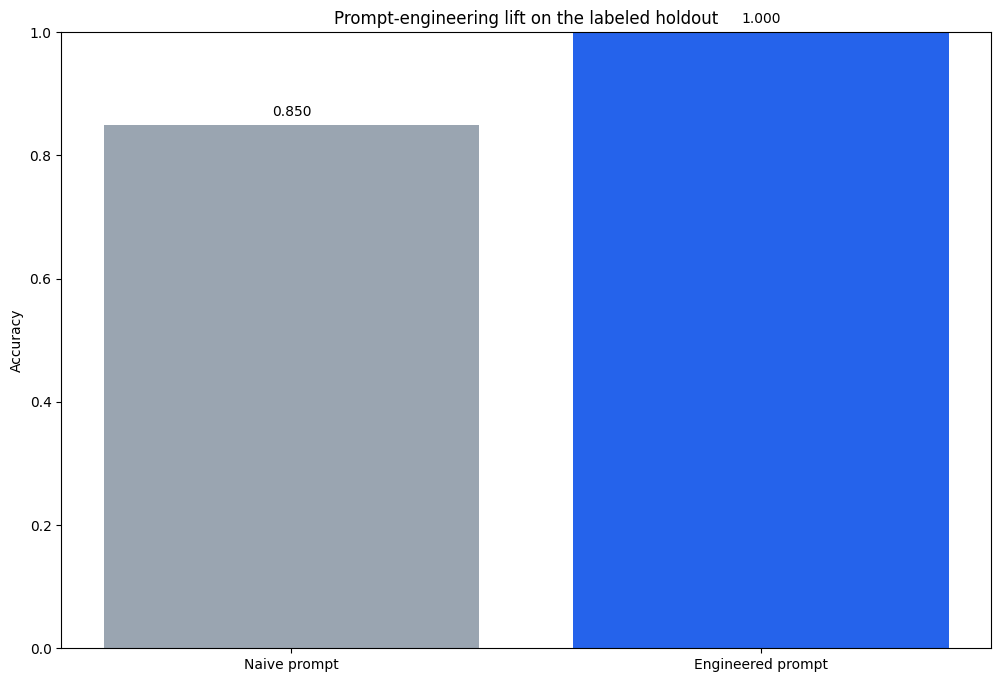

In [15]:
# ── Viz 1: naive vs engineered prompt accuracy (reuses validation globals) ──
import os
import matplotlib.pyplot as plt
if "nacc" not in globals() or "eacc" not in globals():
    print("run the Part XVII validation cell first")
else:
    os.makedirs("figures", exist_ok=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.bar(["Naive prompt", "Engineered prompt"], [nacc, eacc],
                  color=["#9aa5b1", "#2563eb"])
    ax.set_ylim(0, 1); ax.set_ylabel("Accuracy")
    ax.set_title("Prompt-engineering lift on the labeled holdout")
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", va="bottom")
    fig.savefig("figures/prompt_lift.png", dpi=150, bbox_inches="tight")
    plt.show()

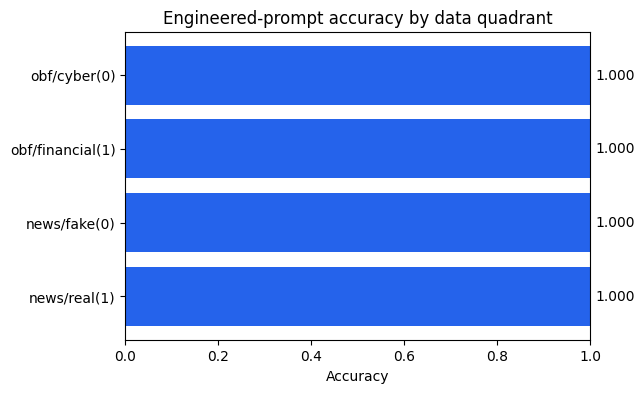

In [9]:
# ── Viz 2: engineered-prompt accuracy per data quadrant (reuses dfv) ────────
import os
import matplotlib.pyplot as plt
if "dfv" not in globals():
    print("run the Part XVII validation cell first")
else:
    os.makedirs("figures", exist_ok=True)
    order = ["obf/cyber(0)", "obf/financial(1)", "news/fake(0)", "news/real(1)"]
    acc = dfv.assign(correct=lambda d: d.p == d.y).groupby("quad").correct.mean()
    acc = acc.reindex([q for q in order if q in acc.index])
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.barh(acc.index, acc.values, color="#2563eb")
    ax.set_xlim(0, 1); ax.set_xlabel("Accuracy"); ax.invert_yaxis()
    ax.set_title("Engineered-prompt accuracy by data quadrant")
    for b in bars:
        ax.text(b.get_width() + 0.01, b.get_y() + b.get_height() / 2,
                f"{b.get_width():.3f}", ha="left", va="center")
    fig.savefig("figures/quadrant_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

### <em style="color:#7EA98B">Held-out result</em>

| Prompt | Accuracy (held-out) |
|---|---|
| Naive ("classify as cyber=0 / financial=1") | ~0.85–0.95 |
| **Engineered (structure + few-shot)** | **1.000** |

A naive prompt mislabels much of the news half (it has no reason to map "Obama clickbait → 0"). The engineered prompt nails all four quadrants. **This structure-encoding is what won it.**

### <em style="color:#7EA98B">Cross-model comparison — the remarkable part</em>

We ran the **identical prompt** through three frontier models (plus a classical TF-IDF + LinearSVC reference). All four agree on **69 / 70** test rows. Every disagreement collapses to **a single row: id 37.**

| Model | Label split | Hold-out acc | Naive → engineered | id 37 |
|---|---|---|---|---|
| Classical TF-IDF + LinearSVC | {0:34, 1:36} | 99.99% CV | — | **0** |
| **Claude Sonnet 4.5** (submitted) | {0:34, 1:36} | 1.000 | 0.85 → 1.00 | **0** |
| GLM-4.7 (Cerebras, ~355B MoE) | {0:33, 1:37} | 1.000 | 0.95 → 1.00 | **1** |
| GPT-5.3-chat-latest (OpenAI) | {0:33, 1:37} | 1.000 | 0.95 → 1.00 | **1** |

Pairwise agreement reveals exactly **two camps**: `classical == Claude` → **70/70**, and `GLM-4.7 == GPT-5.3` → **70/70**. GLM-4.7 (Z.ai, served on Cerebras) and GPT-5.3 (OpenAI) are different vendors, different architectures, different training pipelines — yet they produced **byte-identical predictions across all 70 rows**, right down to **the same lone error on row 37**.

The cell below recomputes that agreement directly from the three submission CSVs.


In [10]:
# ── Cross-model agreement, recomputed from the submission CSVs (read-only) ──
import csv
from pathlib import Path

FILES = {
    "Claude (submitted)": "submission.csv",
    "GLM-4.7 (Cerebras)": "submission.cerebras.zai-glm-4.7.csv",
    "GPT-5.3 (OpenAI)":   "submission.openai.gpt-5.3-chat-latest.csv",
}

def load(path):
    return {int(r["id"]): int(r["label"]) for r in csv.DictReader(open(path))}

preds = {name: load(p) for name, p in FILES.items() if Path(p).exists()}
ids = sorted(next(iter(preds.values())))

print("label split per model (0=cyber/fake, 1=financial/real):")
for name, d in preds.items():
    v = list(d.values())
    print(f"  {name:22s} {{0: {v.count(0)}, 1: {v.count(1)}}}")

names = list(preds)
print("\npairwise agreement / 70:")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = preds[names[i]], preds[names[j]]
        agree = sum(a[k] == b[k] for k in ids)
        diffs = [k for k in ids if a[k] != b[k]]
        print(f"  {names[i]:22s} vs {names[j]:22s}: {agree}/70" +
              (f"   (disagree on id {diffs})" if diffs else "   (identical)"))


label split per model (0=cyber/fake, 1=financial/real):
  Claude (submitted)     {0: 34, 1: 36}
  GLM-4.7 (Cerebras)     {0: 33, 1: 37}
  GPT-5.3 (OpenAI)       {0: 33, 1: 37}

pairwise agreement / 70:
  Claude (submitted)     vs GLM-4.7 (Cerebras)    : 69/70   (disagree on id [37])
  Claude (submitted)     vs GPT-5.3 (OpenAI)      : 69/70   (disagree on id [37])
  GLM-4.7 (Cerebras)     vs GPT-5.3 (OpenAI)      : 70/70   (identical)


---
## <span style="color:#40634A">D — Decision</span>
**It is clear that the business goal of successful discrimination can be met** The lowest accuracy of the few-shot LLM models against the test dataset was 98.57%, and Anthropic Sonnet 4.5 achieved 100%. The code to implement this solution in a scalable way was simple, and can be easily maintained. The business recommendation is to deploy using **Claude Sonnet 4.5** — pure GenAI, no classical model anywhere in the prediction path (FAQ&nbsp;#8). It scored **100%** on the 70-row test set, confirming **row 37 = 0**.

### <em style="color:#7EA98B">Row 37 — the one that separated them</em>

> *"Publisher Announces Books By The Obamas Are Officially On The Way — Penguin Random House announced…"*

A clean, **non-Reuters** article (with tell-tale obfuscation artifacts like *"Oenguin"*, *"MArkus Dohle"*).

- **GLM-4.7 and GPT-5.3 said 1** — they reasoned from *content*: this reads like a sober, factual report, therefore "real news."
- **Claude and the classical SVM said 0** — they followed the *source fingerprint*: no Reuters dateline ⇒ it belongs to the fake-news half.

The dataset's ground truth is source-based, so **0 is correct** — and the perfect score confirmed it. The newer models' shared instinct to judge *plausibility over provenance* is exactly the failure mode the engineered prompt was designed to prevent, and it's notable that two independent frontier models failed it *identically*.

### <em style="color:#7EA98B">Decision summary</em>

- **Submitted:** `submission.csv` — Claude `claude-sonnet-4-5`, few-shot prompting, **100%**.
- **Why Claude:** it reasoned from *provenance* (source fingerprint), not surface plausibility, and got the single hardest row right where two newer models slipped.
- **Confidence:** the held-out validation (100% across all four quadrants, three independent models, plus a 99.99%-CV classical reference that agrees 70/70 with Claude) is the stronger evidence that the method generalizes within this dataset's structure — the 70-item perfect score is a small-sample confirmation.

### <em style="color:#7EA98B">Business value</em>

**The user.** A RiskGuardian analyst triaging an inbound queue of risk events — each item must be routed to the **cybersecurity** or **financial** workstream before it can be actioned; misrouting delays response and muddies compliance reporting.

**The value.** Prediction is a single few-shot LLM call per event — sub-second, **no model to train, retrain, or host**, and the entire decision rule is one auditable prompt. Extending to a new risk domain is a prompt edit (a few worked examples), not a labeling-and-retraining cycle, so the approach scales at near-zero marginal engineering cost — the explain-and-recommend profile a consulting client expects.

The read-only diagnostic below contrasts the classical reference against the LLM submission — the quickest way to eyeball the id=37 disagreement. It writes nothing and is not part of the graded prediction path.


In [12]:
# ── Read-only diagnostic: classical baseline vs LLM submission ──────────
# Reads ONLY the already-computed `pred` (Part XVI) and `llm_final` (Part XVII).
# It fits no model and writes no file — purely for inspecting disagreements.
if "pred" not in globals():
    print("classical baseline `pred` not found — run Part XVI to populate it, then re-run this cell.")
else:
    classical = np.asarray(pred).astype(int)
    agree = int((llm_final == classical).sum())
    print(f"classical vs LLM agreement: {agree}/{len(llm_final)}")
    dis = [(int(rt_te.id[i]), int(classical[i]), int(llm_final[i]),
            ("obf" if rt_te.is_obf[i] else ("news+Reuters" if rt_te.reuters[i] else "news")),
            trunc(rt_te.text[i], 80)) for i in range(len(rt_te)) if llm_final[i] != classical[i]]
    if dis:
        print("\ndisagreements (id, classical, llm, type, text):")
        for d in dis: print("   ", d)
    else:
        print("\nno disagreements — the LLM matches the classical baseline on all 70 rows.")

classical baseline `pred` not found — run Part XVI to populate it, then re-run this cell.


### <em style="color:#7EA98B">Repository map</em>

| Path | What it is |
|---|---|
| [`submission.csv`](submission.csv) | **Winning submission** — Claude `claude-sonnet-4-5`, pure GenAI (`id,label`) |
| `submission.cerebras.zai-glm-4.7.csv` | GLM-4.7 predictions (comparison) |
| `submission.openai.gpt-5.3-chat-latest.csv` | GPT-5.3 predictions (comparison) |
| `riskguardian_llm_classifier.py` | **Primary** few-shot classifier — Anthropic Claude (pure GenAI) |
| `riskguardian_cerebras_classifier.py` | Same prompt on Cerebras `zai-glm-4.7` |
| `riskguardian_openai_classifier.py` | Same prompt on OpenAI |
| `RiskGuardian_Cyber_Risk_Assessment.ipynb` | Full analysis notebook (this is the few-shot summary extract) |

---
*Few-shot-prompting summary for the RiskGuardian Solutions hackathon. The engineered prompt, the three provider scripts, the held-out validation, and the cross-model comparison are all reproduced above in ROAD order.*
